# GLMMs to predict syllable probability

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.spatial import distance_matrix, distance
from skbio.stats.composition import clr, closure, multi_replace
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM  as binomial

# Get my functions
functions_path =  prefix + 'representation_learning_variability/Functions/'
os.chdir(functions_path)
# from data_processing import save_and_log
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//2_fit_models/'
os.chdir(functions_path)
from preprocessing_functions import idxs_from_files
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial/4_analyses/5_clustering_analyses/'
os.chdir(functions_path)
# from clustering_functions import calculate_entropy
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette
from one.api import ONE
one = ONE(mode='remote')

# DATA

In [3]:
# Get timing info
data_path = prefix + 'representation_learning_variability/paper-individuality/fig1_segmentation/'
states_file = pd.read_parquet(data_path+'states_trial_type_09-29-2025')

In [4]:
# states_file['trial_type'] = states_file['correct'].astype(str) + states_file['choice'].astype(str) + states_file['contrast'].astype(str) + states_file['block'].astype(str)
states_file['trial_type'] = states_file['correct'].astype(str) + states_file['choice'].astype(str)
syllable_df = states_file[['mouse_name', 'session', 'most_likely_states', 'trial_type', 'trial_id', 'broader_label']]

In [5]:
del states_file

## Get metadata

In [ ]:
sessions = syllable_df.session.unique()
metadata = pd.DataFrame(columns=['session', 'lab'], index=range(len(sessions)))
for s, session in enumerate(sessions):
    session_details = one.get_details(session, full=False)
    metadata['session'][s] = session
    metadata['lab'][s] = session_details['lab']
metadata.to_parquet(prefix + 'representation_learning_variability/paper-individuality/fig5_mixed_models/metadata_13-01-2026', compression='gzip') 

/tmp/ipykernel_7540/2117469269.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metadata['session'][s] = session
/tmp/ipykernel_7540/2117469269.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are sett

In [6]:
metadata = pd.read_parquet(prefix + 'representation_learning_variability/paper-individuality/fig5_mixed_models/metadata_13-01-2026')

In [8]:
# metadata = pd.read_parquet( prefix + 'representation_learning_variability/paper-individuality/fig5_mixed_models/metadata_01-11-2026')
data_path = prefix + 'representation_learning_variability/paper-individuality/fig4_clustering/'
cluster_df = pd.read_parquet(data_path+'5_mouse_cluster_coef')

In [9]:
# cluster_df = pd.read_parquet(data_path+'8_cluster_per_mouse_trial')

In [10]:
syllable_df = syllable_df.merge(metadata[['session', 'lab']])
syllable_df = syllable_df.merge(cluster_df[['mouse_name', 'mouse_cluster']], on='mouse_name', how='outer')

In [11]:
len(syllable_df.mouse_name.unique())

70

### Minimum number of sessions per mouse

In [12]:
session_count = syllable_df[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']
syllable_df = syllable_df.loc[syllable_df['mouse_name'].isin(multi_sess_mice)]

### Minimum number of trials per mouse and unique trials

In [13]:
tria = syllable_df[['mouse_name', 'session', 'trial_id']].drop_duplicates()
min_trial = np.min(tria.groupby(['mouse_name'])['trial_id'].count())

syllable_df = syllable_df.sort_values(["mouse_name", "session", "trial_id"])
syllable_df["trial_global"] = (syllable_df.groupby(["mouse_name", "session", "trial_id"]).ngroup())

In [14]:
print(min_trial)

1386


In [15]:
def subsample_trials_per_mouse(df, n_trials, random_state=None):
    rng = np.random.default_rng(random_state)

    sampled_trials = (df[["mouse_name", "trial_global"]]
                      .drop_duplicates().groupby("mouse_name")
                      .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
                        random_state=rng.integers(1e9))).reset_index(drop=True))

    return df.merge(sampled_trials, on=["mouse_name", "trial_global"])


## Predict syllable x epoch 
- no trial type
- for clustering of mice

In [25]:
group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster']

# Count syllables per group
data = (
    syllable_df
    .groupby(group_cols + ['most_likely_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session', 'lab', 'mouse_cluster']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['most_likely_states', 'broader_label']).reset_index().fillna(0)


In [26]:
df = pd.DataFrame()
df['mouse_name'] = data.mouse_name
df['mouse_cluster'] = data.mouse_cluster
# df['type'] = data.trial_type
df['lab'] = data.lab
df['lab_mouse'] = data.lab + data.mouse_name
# df['finger'] = data.mouse_cluster

syll = syllable_df.most_likely_states.astype(str) + syllable_df.broader_label
syll = syll.unique()

y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
y_log = np.log(y + 1e-6)
y = (y_log - y_log.mean(axis=0, keepdims=True)) / y_log.std(axis=0, keepdims=True)


/tmp/ipykernel_9416/3658653758.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'


In [27]:
results = pd.DataFrame(columns=['syllable', 'mouse_var', 'lab_var', 'resid_var', 'converged'], index=range(len(syll)))

formula = 'syll ~ mouse_name'
vc_form = {'lab': '0 + C(lab)'}

groups = df['lab']
# groups = pd.Series(np.zeros(len(df)))  # dummy
vc_form = {'lab': '0 + C(lab)',
        'mouse_name': '0 + C(mouse_name)'
        }
vc_form = {'lab': '0 + C(lab)',
        'mouse_name': '0 + C(mouse_name)'
        }
# vc_form = {'mouse_cluster': '0 + C(mouse_cluster)',
#            'lab': '0 + C(lab)',
#            }

for i, sy in enumerate(range(127)):
    df['syll'] = y[:, i]
    model = smf.mixedlm(
        formula,
        data=df,
        groups=groups #, vc_formula=vc_form
        )
    res = model.fit()

    # Mouse variance
    var_mouse = res.cov_re.iloc[0,0] if res.cov_re.shape[0] > 0 else 0
    var_mouse = res.vcomp[0] if len(res.vcomp) > 0 else 0
    # Lab variance
    var_lab = res.vcomp[1] if len(res.vcomp) > 0 else 0
    # Residual variance
    var_resid = res.scale

    results['syllable'][i]= i
    results['mouse_var'][i]= var_mouse
    results['lab_var'][i]= var_lab
    results['resid_var'][i]= var_resid
    results['converged'][i] = res.converged

    print(res.summary())

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       syll     
No. Observations:        180           Method:                   REML     
No. Groups:              10            Scale:                    0.6937   
Min. group size:         9             Log-Likelihood:           -202.6567
Max. group size:         38            Converged:                Yes      
Mean group size:         18.0                                             
--------------------------------------------------------------------------
                            Coef.    Std.Err.     z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                   -0.248        0.931 -0.266 0.790 -2.073  1.577
mouse_name[T.CSH_ZAD_026]    0.774        0.538  1.441 0.150 -0.279  1.828
mouse_name[T.CSH_ZAD_029]    0.168        0.559  0.301 0.763 -0.927  1.263
mouse_name[T.DY_016]         0.798        1.

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       syll     
No. Observations:        180           Method:                   REML     
No. Groups:              10            Scale:                    0.4341   
Min. group size:         9             Log-Likelihood:           -169.6096
Max. group size:         38            Converged:                Yes      
Mean group size:         18.0                                             
--------------------------------------------------------------------------
                            Coef.    Std.Err.     z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                    0.991        0.737  1.345 0.179 -0.453  2.435
mouse_name[T.CSH_ZAD_026]   -0.603        0.425 -1.419 0.156 -1.437  0.230
mouse_name[T.CSH_ZAD_029]   -0.773        0.442 -1.750 0.080 -1.640  0.093
mouse_name[T.DY_016]         0.003        1.

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

...

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       syll     
No. Observations:        180           Method:                   REML     
No. Groups:              10            Scale:                    0.8942   
Min. group size:         9             Log-Likelihood:           -220.5513
Max. group size:         38            Converged:                Yes      
Mean group size:         18.0                                             
--------------------------------------------------------------------------
                            Coef.    Std.Err.     z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                    0.787        1.057  0.744 0.457 -1.285  2.859
mouse_name[T.CSH_ZAD_026]    0.172        0.610  0.282 0.778 -1.024  1.368
mouse_name[T.CSH_ZAD_029]   -1.063        0.634 -1.675 0.094 -2.306  0.181
mouse_name[T.DY_016]        -1.063        1.

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       syll     
No. Observations:        180           Method:                   REML     
No. Groups:              10            Scale:                    0.3624   
Min. group size:         9             Log-Likelihood:           -156.8720
Max. group size:         38            Converged:                Yes      
Mean group size:         18.0                                             
--------------------------------------------------------------------------
                            Coef.    Std.Err.     z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                    0.504        0.673  0.749 0.454 -0.815  1.823
mouse_name[T.CSH_ZAD_026]   -1.645        0.389 -4.232 0.000 -2.406 -0.883
mouse_name[T.CSH_ZAD_029]   -1.654        0.404 -4.097 0.000 -2.446 -0.863
mouse_name[T.DY_016]        -2.073        0.

/tmp/ipykernel_9416/2570111257.py:35: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  results['syllable'][i]= i
/tmp/ipykernel_9416/2570111257.py:36: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting v

In [17]:
def fit_lmm(df, y, syll, formula, groups, vc_form):
    results = pd.DataFrame(columns=['syllable', 'mouse_var', 'lab_var', 'resid_var', 'converged'], index=range(len(syll)))

    for i, sy in enumerate(syll):
        df['syll'] = y[:, i]
        model = smf.mixedlm(
            formula,
            data=df,
            groups=groups,
            vc_formula=vc_form #, vc_formula=vc_form
            )
        res = model.fit()

        # Mouse variance
        var_mouse = res.cov_re.iloc[0,0] if res.cov_re.shape[0] > 0 else 0
        var_mouse = res.vcomp[1] if len(res.vcomp) > 0 else 0
        # Lab variance
        var_lab = res.vcomp[0] if len(res.vcomp) > 0 else 0
        # Residual variance
        var_resid = res.scale

        results['syllable'][i]= sy
        results['mouse_var'][i]= var_mouse
        results['lab_var'][i]= var_lab
        results['resid_var'][i]= var_resid
        results['converged'][i] = res.converged

        # print(res.summary())
    return results

In [18]:
repeats = 10
all_results = pd.DataFrame()

formula = 'syll ~ 1'
groups = pd.Series(np.zeros(len(df)))  # dummy
vc_form = {'lab': '0 + C(lab)',
        'mouse_name': '0 + C(mouse_name)'}
vc_form = {'mouse_cluster': '0 + C(mouse_cluster)',
           'lab': '0 + C(lab)'}
for r in range(repeats):
    print('Repeat %d of %d' % (r+1, repeats))  

    # Subsample data anew
    subsampled = subsample_trials_per_mouse(syllable_df, min_trial, random_state=None)
    # Count syllables per group
    group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster']
    data = (subsampled
        .groupby(group_cols + ['most_likely_states'])
        .size().reset_index(name='count'))

    # Convert counts to fractions within each group
    data['usage'] = (
        data['count'] /
        data.groupby(group_cols)['count'].transform('sum'))

    group_cols = ['mouse_name', 'session', 'lab', 'mouse_cluster']
    data = pd.pivot_table(data, values='usage', index=group_cols, columns=['most_likely_states', 'broader_label']).reset_index().fillna(0)

    df = pd.DataFrame()
    df['mouse_name'] = data.mouse_name
    df['mouse_cluster'] = data.mouse_cluster
    # df['type'] = data.trial_type
    df['lab'] = data.lab
    df['lab_mouse'] = data.lab + data.mouse_name
    # df['finger'] = data.mouse_cluster

    syll = syllable_df.most_likely_states.astype(str) + syllable_df.broader_label
    syll = syll.unique()
    syll = np.array(data.keys()[4:])
    
    y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
    y_log = np.log(y + 1e-6)
    y = (y_log - y_log.mean(axis=0, keepdims=True)) / y_log.std(axis=0, keepdims=True)

    # Fit LMM
    results = fit_lmm(df, y, syll, formula, groups, vc_form)
    results['repeat'] = r

    # Save results
    all_results = pd.concat([all_results, results])
    
    # # Save results
    # samplings_df.loc[r, 'repeat'] = r
    # samplings_df.loc[r, 'distance_matrix'] = pairwise_matrix


Repeat 1 of 10


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/2801606035.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/1665742735.py:41: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood

Repeat 2 of 10


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/2801606035.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/1665742735.py:41: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/48995635.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Curre

Repeat 3 of 10


...

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/2801606035.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/1665742735.py:41: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/48995635.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Curre

Repeat 9 of 10


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/2801606035.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/1665742735.py:41: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/48995635.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Curre

Repeat 10 of 10


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/2801606035.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_trials, len(x)), replace=False,
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/1665742735.py:41: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster'], axis=1).to_numpy()  # , 'broader_label'
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood

In [19]:
all_results[['syllable', 'epoch']] = pd.DataFrame(all_results['syllable'].tolist(), index=all_results.index)


In [20]:
identifiable_mapping = {'000': 0.0,
           '100': 1.0,
           '200': 2.0,
           '300': 3.0,
           '400': 4.0,
           '500': 5.0,
           '600': 6.0,
           '700': 7.0,
           
           '010': 8.0,
           '110': 9.0,
           '210': 10.0,
           '310': 11.0,
           '410': 12.0,
           '510': 13.0,
           '610': 14.0,
           '710': 15.0,

           '001': 16.0,
           '101': 17.0,
           '201': 18.0,
           '301': 19.0, 
           '401': 20.0, 
           '501': 21.0, 
           '601': 22.0, 
           '701': 23.0, 

           '011': 24.0,
           '111': 25.0,
           '211': 26.0,
           '311': 27.0,
           '411': 28.0,
           '511': 29.0,
           '611': 30.0,
           '711': 31.0,
           'nan': np.nan
           }
    # paw_mapping = {0:4, 1:1, 2:5, 3:7, 4:6, 5:2, 6:0, 7:3}
inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
replace_func = np.vectorize(inverted_mapping.get)

In [21]:
all_results['mouse_icc'] = all_results['mouse_var']/(all_results['mouse_var']+all_results['lab_var']+all_results['resid_var'])
all_results['lab_icc'] = all_results['lab_var']/(all_results['mouse_var']+all_results['lab_var']+all_results['resid_var'])

In [22]:
var_df = all_results.copy()
var_df = all_results.loc[all_results['converged']==True]
var_df['identifiable_states'] = replace_func(var_df['syllable'])
var_df = pd.melt(var_df, id_vars=['repeat', 'epoch', 'identifiable_states'], value_vars=['mouse_icc', 'lab_icc'])

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7204/3326707411.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var_df['identifiable_states'] = replace_func(var_df['syllable'])


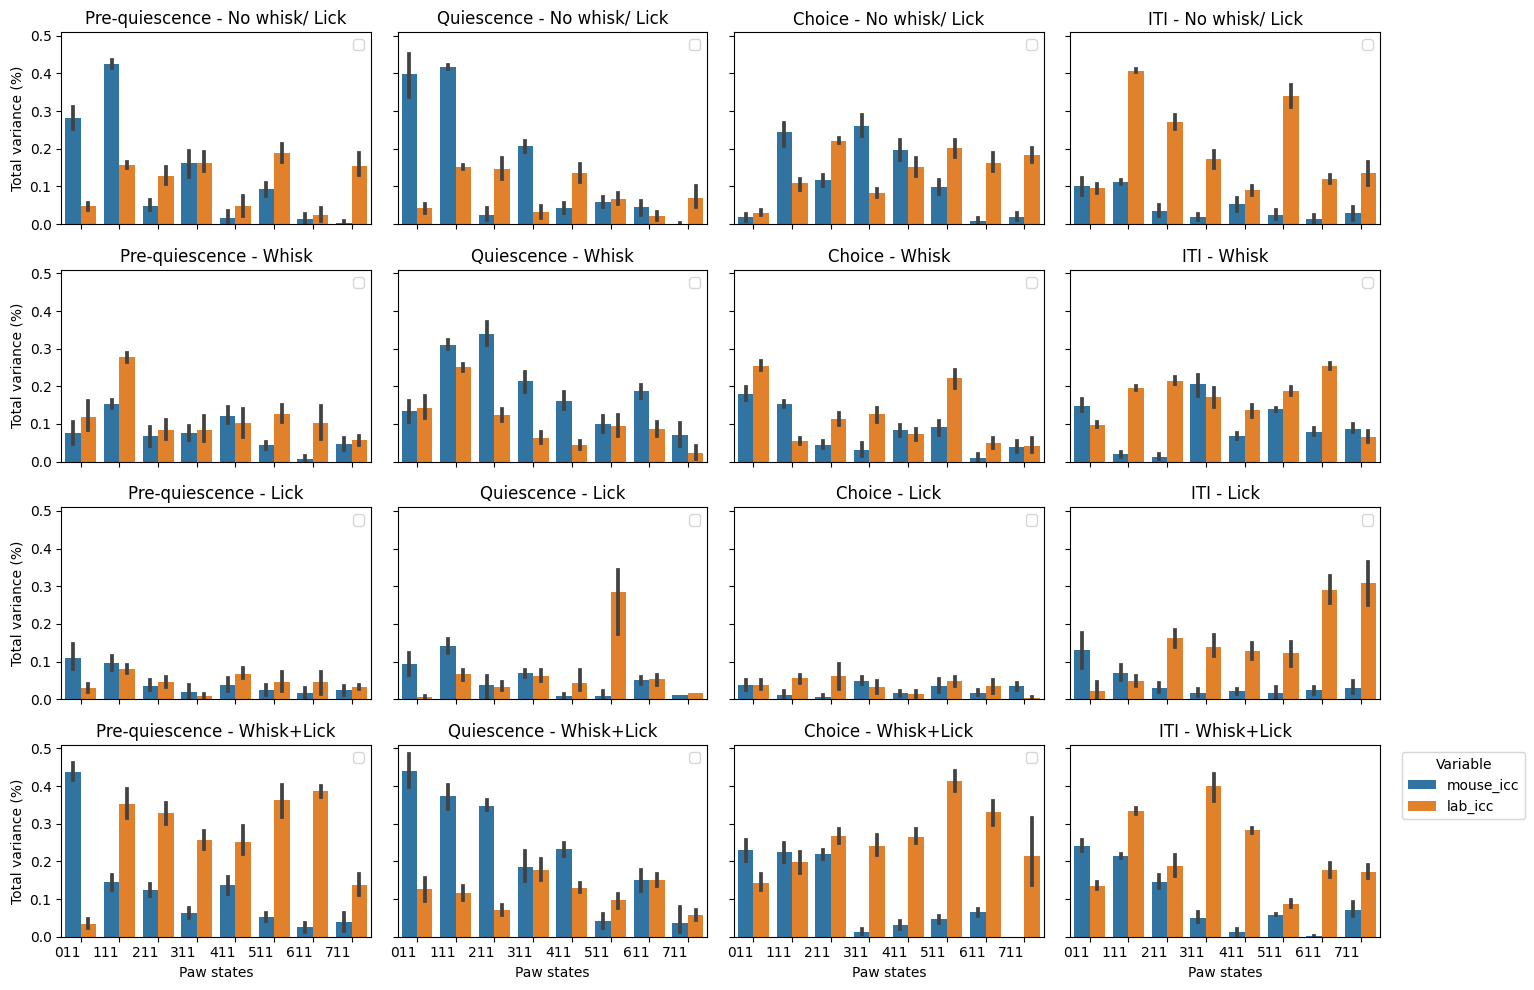

In [23]:
syllable_labels = [['000', '100', '200', '300', '400', '500', '600', '700'],
                   ['010', '110', '210', '310', '410', '510', '610', '710'],
                   ['001', '101', '201', '301', '401', '501', '601', '701'],
                   ['011', '111', '211', '311', '411', '511', '611', '711']]

titles = ['No whisk/ Lick', 'Whisk', 'Lick', 'Whisk+Lick']
epochs = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharey=True, sharex=True)

for i in range(4):
    use_syllables = syllable_labels[i]
    use = var_df.loc[var_df['identifiable_states'].isin(use_syllables)]
    for e, epoch in enumerate(epochs):
        use_data = use.loc[use['epoch']==epoch]
        sns.barplot(
            data=use_data,
            x="identifiable_states",
            y="value",
            hue="variable",
            ax=axes[i, e])
        
        axes[i, e].set_xticks(range(len(use_syllables)))  # or specify labels explicitly if needed
        axes[3, e].set_xticklabels(use_syllables, ha='right')
        if e == 0:
            axes[i, e].set_ylabel("Total variance (%)")
        else:
            axes[i, e].set_ylabel("")
        axes[i, e].set_title(epoch+' - '+titles[i])  # optional title per subplot
        axes[i, e].legend('')
        axes[i, e].set_xlabel('')
        axes[3, e].set_xlabel("Paw states")
# Optional: adjust layout and legend
plt.tight_layout()
plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [47]:
total_var = var_mouse + var_lab + var_resid
icc_mouse = var_mouse / total_var
icc_lab = var_lab / total_var
icc_mouse_lab = (var_mouse + var_lab) / total_var

## Per trial

In [423]:
df['y_lab_centered'] = (
    df['y'] - data.groupby('lab')['y'].transform('mean')
)

KeyError: 'y'

In [443]:
group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster', 'trial_type', 'trial_id']
# group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster', 'trial_type']

# Count syllables per group
data = (
    syllable_df
    .groupby(group_cols + ['most_likely_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

In [444]:
data

,mouse_name,session,broader_label,lab,mouse_cluster,trial_type,trial_id,most_likely_states,count,usage
0,CSH_ZAD_019,49e0ab27-827a-4c91-bcaa-97eea27a1b8d,Choice,zadorlab,4.0,0.0left,4.0,1.0,14,0.101449
1,CSH_ZAD_019,49e0ab27-827a-4c91-bcaa-97eea27a1b8d,Choice,zadorlab,4.0,0.0left,4.0,3.0,7,0.050725
2,CSH_ZAD_019,49e0ab27-827a-4c91-bcaa-97eea27a1b8d,Choice,zadorlab,4.0,0.0left,4.0,8.0,2,0.014493
3,CSH_ZAD_019,49e0ab27-827a-4c91-bcaa-97eea27a1b8d,Choice,zadorlab,4.0,0.0left,4.0,9.0,33,0.239130
4,CSH_ZAD_019,49e0ab27-827a-4c91-bcaa-97eea27a1b8d,Choice,zadorlab,4.0,0.0left,4.0,10.0,7,0.050725
...,...,...,...,...,...,...,...,...,...,...
1560964,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,Quiescence,wittenlab,2.0,1.0right,425.0,9.0,2,0.051282
1560965,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,Quiescence,wittenlab,2.0,1.0right,426.0,1.0,29,0.966667
1560966,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,Quiescence,wittenlab,2.0,1.0right,426.0,9.0,1,0.033333
1560967,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,Quiescence,wittenlab,2.0,1.0right,427.0,1.0,19,0.633333


In [475]:
group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster', 'trial_type', 'trial_id']
# group_cols = ['mouse_name', 'session', 'broader_label', 'lab', 'mouse_cluster', 'trial_type']

# Count syllables per group
data = (
    syllable_df
    .groupby(group_cols + ['most_likely_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

data['lab_mean'] = data.groupby(['lab', 'broader_label', 'trial_type', 'most_likely_states'])['usage'].transform('mean')
data['lab_subtracted'] = data['usage']-data['lab_mean']

group_cols = ['mouse_name', 'session', 'lab', 'mouse_cluster','trial_type', 'trial_id']
# group_cols = ['mouse_name', 'session', 'lab', 'mouse_cluster','trial_type']
# data = pd.pivot_table(data, values='usage', index=group_cols, columns=['most_likely_states', 'broader_label']).reset_index().fillna(0)
data = pd.pivot_table(data, values='lab_subtracted', index=group_cols, columns=['most_likely_states', 'broader_label']).reset_index().fillna(0)



In [211]:
data = data.sort_values(by=['lab', 'mouse_cluster', 'mouse_name', 'session', 'trial_type', 'trial_id'])

KeyError: 'trial_id'

In [482]:
df = pd.DataFrame()
df['mouse_name'] = data.mouse_name
df['mouse_cluster'] = data.mouse_cluster
df['trial_type'] = data.trial_type
df['lab'] = data.lab
df['lab_mouse'] = data.lab + data.mouse_name
df['session'] = data.session

syll = syllable_df.most_likely_states.astype(str) + syllable_df.broader_label
syll = syll.unique()
syll = np.array(data.keys()[6:])

y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster', 'trial_type', 'trial_id'], axis=1).to_numpy()  # , 'broader_label'
# y = data.drop(['mouse_name',  'lab', 'session', 'mouse_cluster', 'trial_type'], axis=1).to_numpy()  # , 'broader_label'
# y_log = np.log(y + 1e-6)
y_log = y
y = (y_log - y_log.mean(axis=0, keepdims=True)) / y_log.std(axis=0, keepdims=True)

/tmp/ipykernel_9928/3184268661.py:13: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



(array([5.7110e+03, 8.1980e+03, 7.2630e+03, 7.8176e+04, 5.5720e+03,
        4.4160e+03, 2.6040e+03, 1.1060e+03, 2.6400e+02, 3.5000e+01]),
 array([-2.97155723, -2.15534625, -1.33913527, -0.5229243 ,  0.29328668,
         1.10949765,  1.92570863,  2.74191961,  3.55813058,  4.37434156,
         5.19055254]),
 <BarContainer object of 10 artists>)

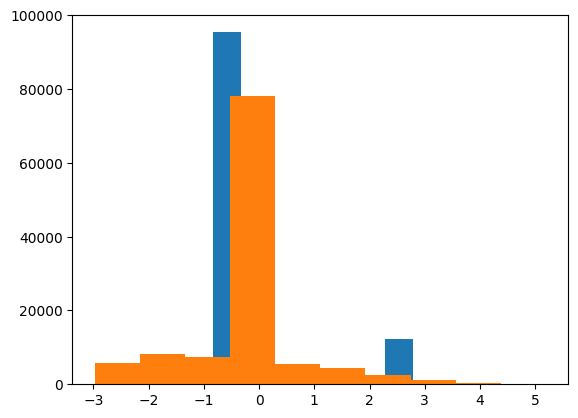

In [436]:
plt.hist(y[:, 2])
plt.hist(y[:, 5])

In [722]:
all_results = pd.DataFrame()
formula = 'syll ~ 0 + C(trial_type) + C(mouse_name) + C(trial_type):C(mouse_name)'
formula = 'syll ~ C(trial_type):C(mouse_name)'
formula = 'syll ~ C(trial_type) + C(mouse_name)'

vc_form = {'lab_mouse': '0 + C(lab_mouse)'}
vc_form = {'lab': '0 + C(lab)'}

groups = df['session']

for i, sy in enumerate(syll):
    df['syll'] = y[:, i]

    model = smf.mixedlm(
        formula,
        data=df,
        groups=groups#,         vc_formula=vc_form
        )
    res = model.fit()
    
    # Mouse variance
    var_session = res.cov_re.iloc[0,0] if res.cov_re.shape[0] > 0 else 0
    # var_mouse = res.vcomp[0] if len(res.vcomp) > 0 else 0
    # Lab variance
    # var_lab = res.vcomp[0] if len(res.vcomp) > 0 else 0
    # Residual variance
    var_resid = res.scale

    results = pd.concat([res.fe_params, res.pvalues], axis=1)
    results = results.rename(columns={0:'coeffs', 1:'p_value'})
    
    results['syllable']= str(sy[0])+str(sy[1])
    results['session_var']= var_session
    # results['lab_var'] = var_lab
    results['resid_var'] = var_resid
    results['converged'] = res.converged
    
    all_results = pd.concat([all_results, results])
    
    # print(res.summary())


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning:

Retrying MixedLM optimization with lbfgs

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/s

In [723]:
print(res.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      syll        
No. Observations:      113345       Method:                  REML        
No. Groups:            180          Scale:                   0.9986      
Min. group size:       372          Log-Likelihood:          -161128.2789
Max. group size:       1521         Converged:               No          
Mean group size:       629.7                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      -0.039    0.136 -0.286 0.775 -0.306  0.228
C(trial_type)[T.0.0right]      -0.004    0.015 -0.281 0.779 -0.033  0.025
C(trial_type)[T.1.0left]       -0.003    0.011 -0.239 0.811 -0.024  0.019
C(trial_type)[T.1.0right]      -0.003    0.011 -0.288 0.

In [ ]:
total_var = var_mouse + var_lab + var_resid
icc_mouse = var_mouse / total_var
icc_lab = var_lab / total_var
icc_mouse_lab = (var_mouse + var_lab) / total_var

In [724]:
results_copy = all_results.copy()
results_copy.loc[results_copy['p_value']> 0.05, 'coeffs'] = 0  # Zero non-significant coefficients
results_copy = results_copy.loc[results_copy['converged']==True]  # Remove non converged model results
results_copy = results_copy.reset_index()


In [651]:
pivot_1 = results_copy.reset_index().pivot(index=['index'], columns=['syllable'], values='coeffs').reset_index().dropna()
pivot_1['trial_type'] = pivot_1['index'].str.extract(r'C\(trial_type\)(.*?)C\(mouse_name\)')
pivot_1['mouse_name'] = pivot_1['index'].str.extract(r'C\(mouse_name\)\[(.*?)\]')
pivot_1 = pivot_1.loc[pivot_1['index']!='Intercept']

In [665]:
trial_types = pivot_1['trial_type'].unique()
full_df = pivot_1.loc[pivot_1['trial_type'].isna()]
for i, type in enumerate(['[T.0.0right]:', '[T.1.0left]:', '[T.1.0right]:']):
    use = pivot_1.loc[pivot_1['trial_type']==type]
    # use = np.array(use.drop(columns=['index', 'trial_type', 'mouse_name']).astype(float))
    full_df = full_df.merge(use, on=['mouse_name'])
    # full_df = full_df.drop(columns=['index', 'trial_type', 'mouse_name']).astype(float)
    # full_df =  np.concatenate([full_df, use], axis=1)

mouse_coeffs_array = np.array(full_df)

MergeError: Passing 'suffixes' which cause duplicate columns {'4.0Choice_x', '17.0ITI_x', '5.0Quiescence_x', '2.0Choice_x', '4.0ITI_x', '1.0Pre-quiescence_x', '0.0Choice_x', '14.0ITI_x', '27.0ITI_x', '29.0Quiescence_x', '0.0Pre-quiescence_x', '28.0Pre-quiescence_x', '19.0Choice_x', '17.0Choice_x', '30.0Quiescence_x', '12.0Choice_x', '20.0ITI_x', '6.0ITI_x', '13.0Choice_x', '0.0Quiescence_x', '5.0Pre-quiescence_x', '11.0ITI_x', '6.0Pre-quiescence_x', '23.0ITI_x', '18.0ITI_x', '3.0Choice_x', '31.0Pre-quiescence_x', '8.0ITI_x', '30.0ITI_x', '8.0Pre-quiescence_x', '11.0Pre-quiescence_x', '30.0Choice_x', '14.0Choice_x', '27.0Pre-quiescence_x', '29.0Choice_x', '6.0Quiescence_x', '16.0ITI_x', '2.0Pre-quiescence_x', '22.0ITI_x', '15.0ITI_x', '9.0Pre-quiescence_x', '15.0Choice_x', '16.0Choice_x', '25.0ITI_x', '27.0Choice_x', 'index_x', '31.0Choice_x', '14.0Pre-quiescence_x', '5.0ITI_x', '4.0Pre-quiescence_x', '3.0ITI_x', '7.0Choice_x', '30.0Pre-quiescence_x', '26.0Quiescence_x', '11.0Quiescence

In [694]:
mouse_coeffs_array = np.array(use.drop(columns=['index', 'trial_type', 'mouse_name']))

In [741]:
mouse_coeffs = results_copy.reset_index().pivot(index=['index'], columns=['syllable'], values='coeffs').reset_index().dropna()[:-4]

mouse_coeffs_array = np.array(mouse_coeffs.drop(columns=['index']).astype(float))

In [742]:
mouse_coeffs['trial_type'] = mouse_coeffs['index'].str.extract(r'C\(trial_type\)\[T\.(.*?)\]')
mouse_coeffs['mouse_name'] = mouse_coeffs['index'].str.extract(r'C\(mouse_name\)\[(.*?)\]')

## Clustering

/tmp/ipykernel_9928/1883941004.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



(0.0, 38.0)

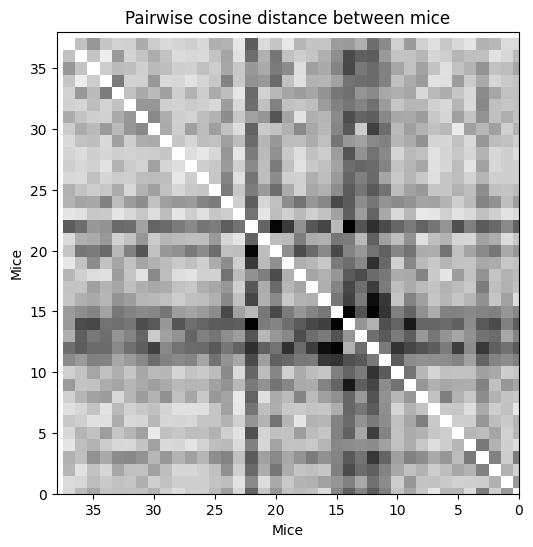

In [743]:
pairwise_matrix = pairwise_distances(mouse_coeffs_array, metric='cosine')

# plt.yticks(np.arange(0, len(mouse_labels)), np.array(mouse_labels))

palette=sns.color_palette('Greys', as_cmap=True)
orig_map=plt.cm.get_cmap('Greys')
# reversing the original colormap using reversed() function
reversed_map = orig_map.reversed()

fig, ax = plt.subplots(figsize=[10, 6])
plt.imshow(pairwise_matrix, cmap=orig_map)
plt.xlabel('Mice')
plt.ylabel('Mice')
plt.title('Pairwise cosine distance between mice')
plt.xlim([np.shape(pairwise_matrix)[0], 0])
plt.ylim([0, np.shape(pairwise_matrix)[0]])

In [739]:
mouse_coeffs = use.reset_index().copy()

/tmp/ipykernel_9928/3282341504.py:10: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



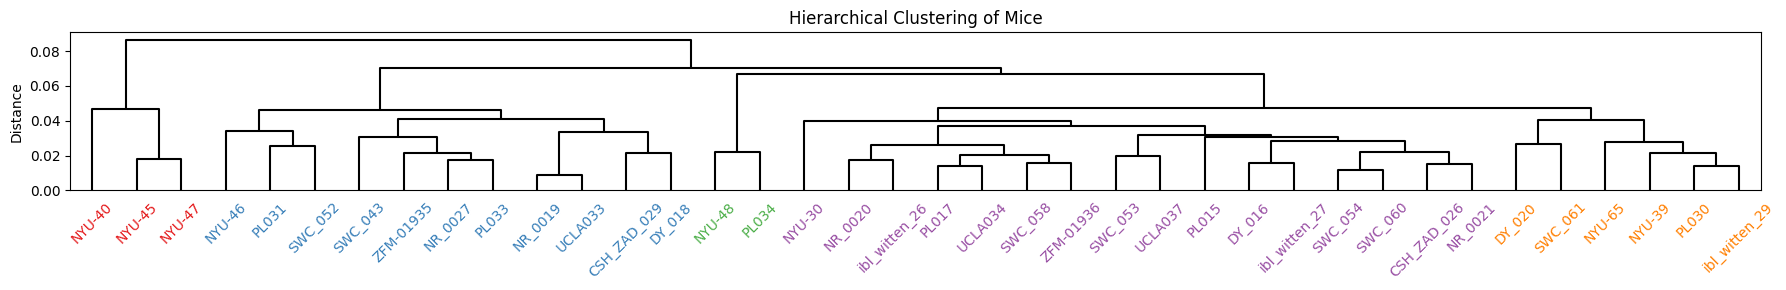

In [744]:
k = 5
mouse_names = mouse_coeffs['index'].str.extract(r'T\.(.*?)\]')[0]
mouse_labels = np.array(mouse_names)

# mouse_labels = np.array(use['mouse_name'])

from scipy.cluster.hierarchy import linkage, dendrogram
# Perform clustering
p = pairwise_matrix
Z = linkage(p.copy(), method='average', metric='cosine')  # You can also try 'complete', 'ward', etc.

# Z = linkage(pairwise_matrix.copy(), method='average', metric='cosine')  # You can also try 'complete', 'ward', etc.

from scipy.cluster.hierarchy import ward, fcluster
# final_clusters = fcluster(Z, t=k, criterion='maxclust')
final_clusters = fcluster(Z, t=k, criterion='maxclust')
final_clusters = final_clusters - 1

# mouse_labels = np.array(full_session_syllables['mouse_name'])#.unique()
# design_df['session_cluster'] = clusters 

# Plot dendrogram
fig, ax = plt.subplots(figsize=(18, 3))

# Define colors for clusters
cmap = plt.get_cmap(sns.color_palette("Set1", k, as_cmap=True))
# cmap = plt.get_cmap(sns.color_palette(k, as_cmap=True))
colors = [cmap(i % cmap.N) for i in range(k)]
cluster_colors = {i: colors[i] for i in range(k)}

# Plot dendrogram with colored labels
dendro = dendrogram(Z, labels=mouse_labels, leaf_font_size=10, ax=ax, 
                    link_color_func=lambda k: "black", leaf_rotation=45)

# Apply colors to tick labels
x_labels = ax.get_xmajorticklabels()
counter = 0
for lbl in x_labels:
    mouse_id = lbl.get_text()
    cluster_id = final_clusters[mouse_labels==mouse_id][0]
    lbl.set_color(cluster_colors[cluster_id])

plt.title("Hierarchical Clustering of Mice")
plt.ylabel("Distance")
plt.tight_layout()

plt.show()

In [720]:
mouse_coeffs['mouse_clusters'] = final_clusters
mouse_coeffs = mouse_coeffs.sort_values(by='mouse_clusters')

In [692]:
mouse_coeffs = use.copy()
mouse_coeffs['mouse_clusters'] = final_clusters
mouse_coeffs = mouse_coeffs.sort_values(by='mouse_clusters')

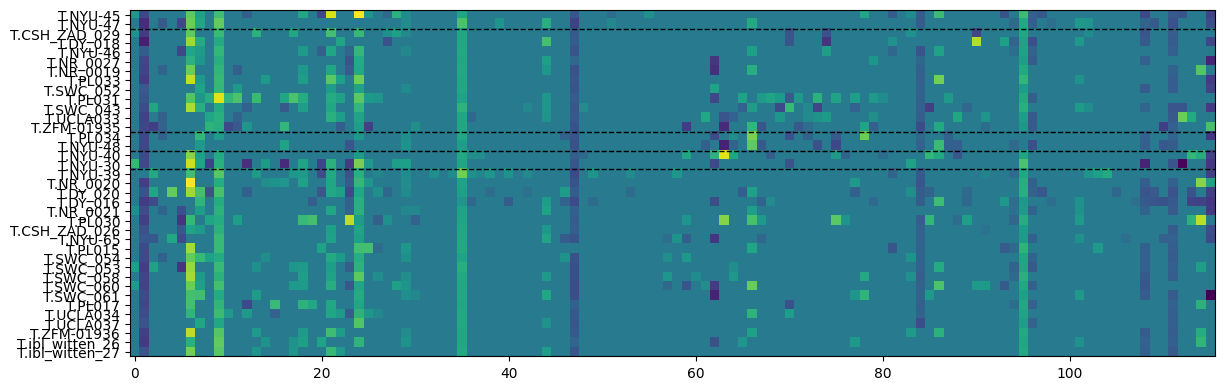

In [721]:
# plot_coeffs = np.array(mouse_coeffs.drop(columns=['index', 'mouse_clusters']).astype(float))
plot_coeffs = mouse_coeffs_array

fig, ax = plt.subplots()
fig.set_size_inches(14,10)
plt.imshow(plot_coeffs)
labels = mouse_coeffs['index'].str.extract(r'T\.(.*?)\]')[0]
labels = np.array(mouse_coeffs['mouse_name'])
plt.yticks(np.arange(0, len(labels), 1), np.array(labels))
plt.axhline(np.where(np.diff(mouse_coeffs['mouse_clusters'])==1)[0][0] - 0.5+1, c='k', ls='--', lw=1)
plt.axhline(np.where(np.diff(mouse_coeffs['mouse_clusters'])==1)[0][1] - 0.5+1, c='k', ls='--', lw=1)
plt.axhline(np.where(np.diff(mouse_coeffs['mouse_clusters'])==1)[0][2] - 0.5+1, c='k', ls='--', lw=1)
plt.axhline(np.where(np.diff(mouse_coeffs['mouse_clusters'])==1)[0][3] - 0.5+1, c='k', ls='--', lw=1)


# PCA

In [360]:
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
from sklearn.decomposition import PCA

In [361]:
X = np.array(mouse_coeffs_array)

In [362]:
n_components = 30
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
standardized_X = scaler.fit_transform(X)
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(X)

Text(0.5, 1.0, 'Explained Variance by PCA')

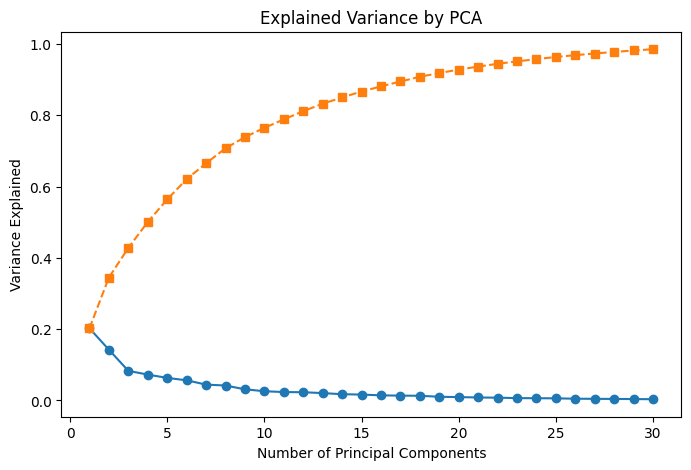

In [363]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [364]:
np.shape(X_pca)

(38, 30)

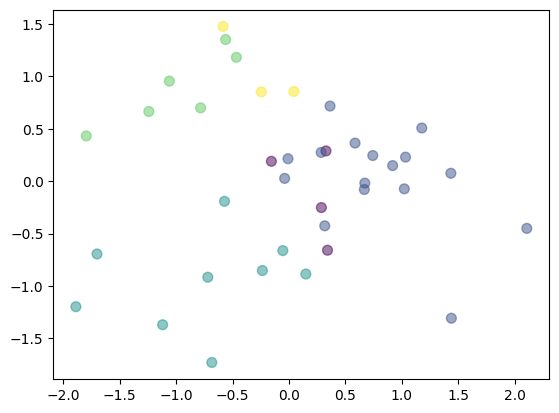

In [365]:
clusters = np.array(final_clusters)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, marker='o', s=50, 
         c=clusters)
# plt.xlim([-10, 10])
# plt.ylim([-10, 10])

# plt.scatter(X_pca[:, 1], size=1)


In [167]:
import plotly.graph_objects as go

# Create trace, sizing bubbles by planet diameter
fig = go.Figure(data=go.Scatter3d(
    x = X_pca[:, 0],
    y = X_pca[:, 1],
    z = X_pca[:, 2],
    mode = 'markers',
    marker = dict(
        color = final_clusters,
        )
))
fig.show()

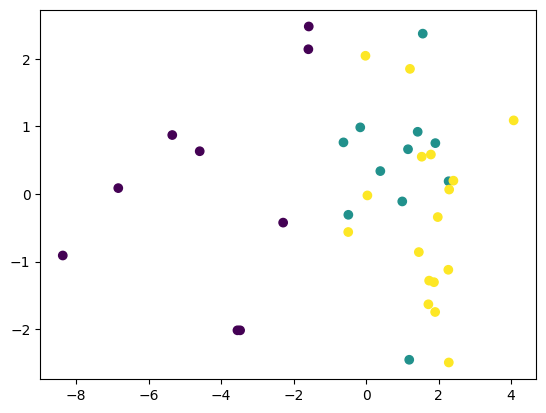

In [168]:
cmap = plt.get_cmap(sns.color_palette("tab10", k, as_cmap=True))
# cmap = plt.get_cmap(sns.color_palette(k, as_cmap=True))
colors = [cmap(i % cmap.N) for i in range(k)]
cluster_colors = {i: colors[i] for i in range(k)}
plt.scatter(X_pca[:, 0], X_pca[:, 4], c=final_clusters)